In [25]:
from pathlib import Path
import os

from astropy.nddata import CCDData
from astropy.visualization import hist
import ccdproc as ccdp
import matplotlib.pyplot as plt
import numpy as np

from convenience_functions import show_image

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


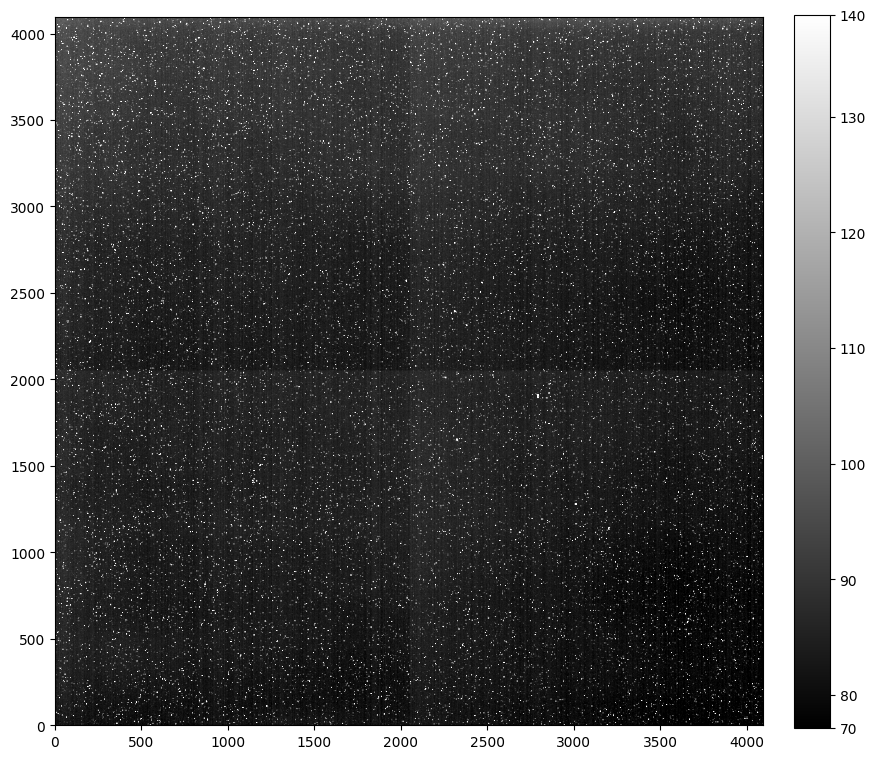

In [27]:
###########################################
## Part I: Performing Overscan and Trim: ##
###########################################
ppath = Path('C:\\Users\\Observatory\\Exo\\Data\\test3-psr')
files = ccdp.ImageFileCollection(ppath)
raw_im = files.files_filtered(include_path=True, OBSTYPE='dark')
##Part II: Performing Trim 

### Veiwing a single file in order to decide about necessary trim dimentions:

first_im = CCDData.read(raw_im[0], unit='adu')
show_image(first_im.data, cmap='gray')

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
(1500, 1500)


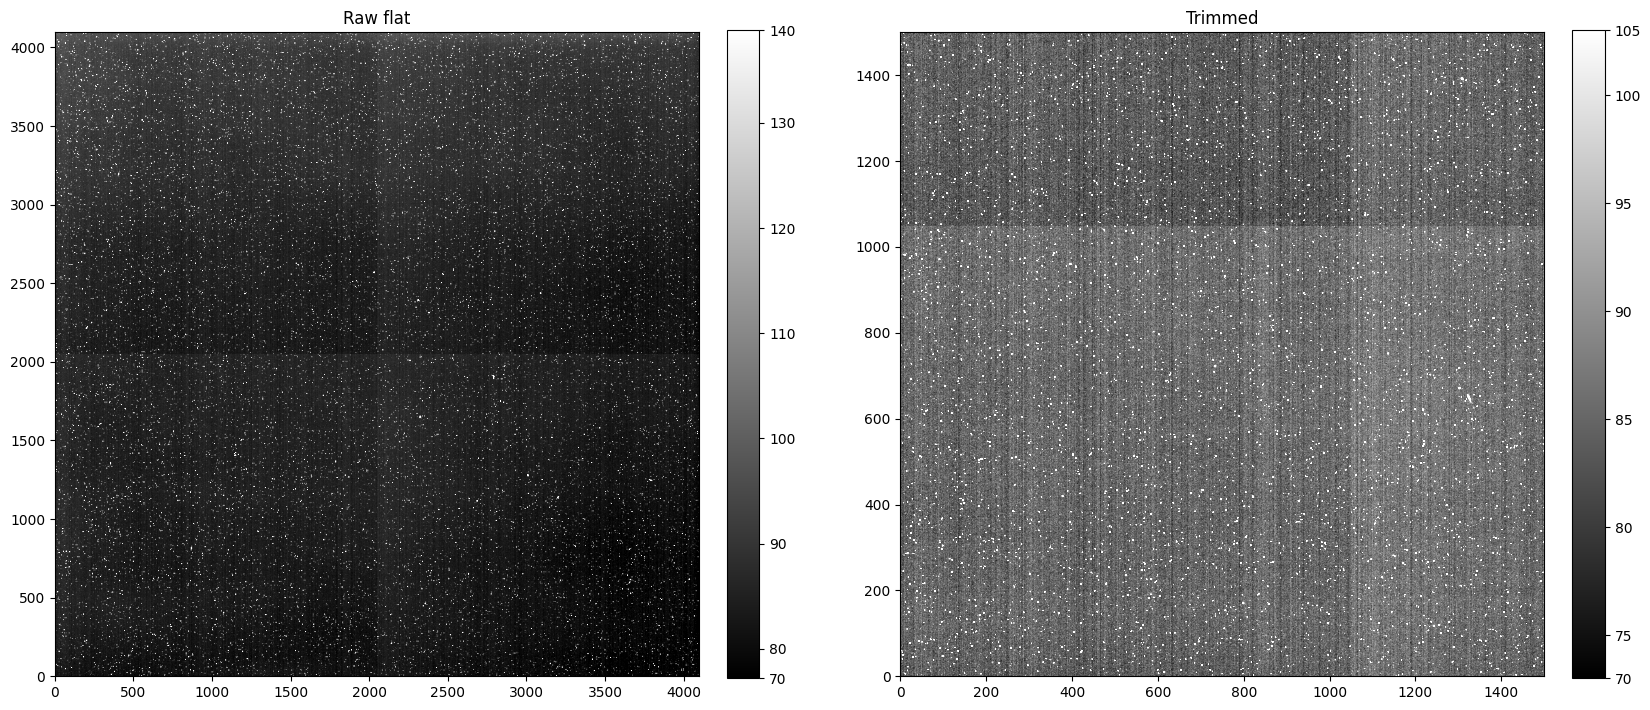

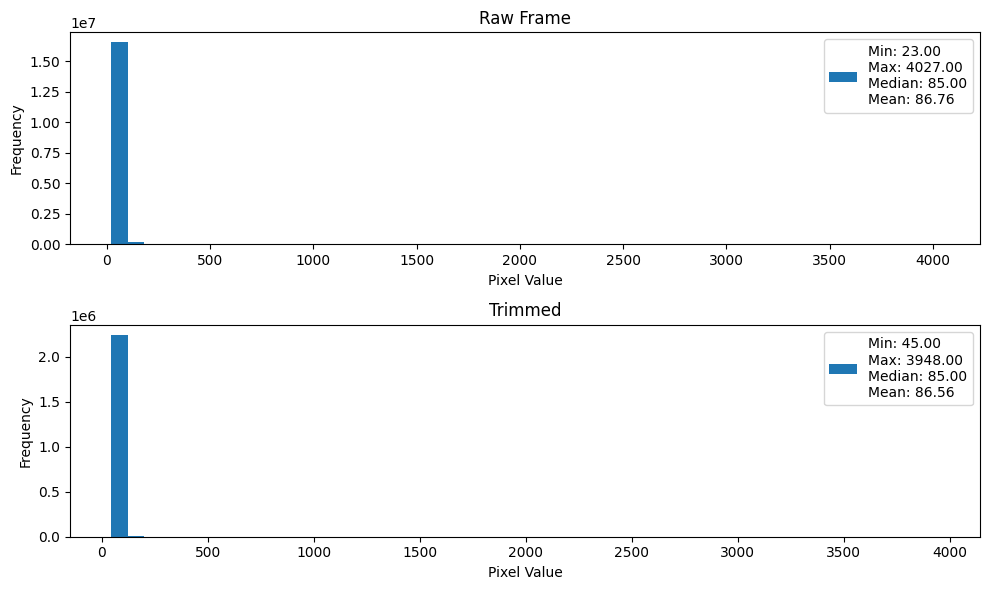

In [31]:
## I choose not to correct for overscan and just perform trim
## This part does the job for a single frame in each category but it allows to set the trim regions for the
## bulk action at the end of this routine:

## specify which type of file you want to work on
raw = files.files_filtered(include_path=True, OBSTYPE='dark')
first_file = CCDData.read(raw[0], unit='adu')


# Trim the image to the desired size
trimmed_file = ccdp.trim_image(first_file[1000:2500, 1000:2500])
print(trimmed_file.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
#plt.imshow(first_file.data,vmin=0,vmax=1000,origin='lower')
show_image(first_file.data, cmap='gray', ax=ax1, fig=fig)
ax1.set_title('Raw flat')
show_image(trimmed_file.data, cmap='gray', ax=ax2, fig=fig)
ax2.set_title('Trimmed')
#fig.savefig("IC10_flat1_Trimonly.png")


# Create histograms
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.hist(first_file.data.flatten(), bins=50)
plt.title("Raw Frame")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
min_val = np.min(first_file.data)
max_val = np.max(first_file.data)
median_val = np.median(first_file.data)
mean_val = np.mean(first_file.data)
plt.legend([f'Min: {min_val:.2f}\nMax: {max_val:.2f}\nMedian: {median_val:.2f}\nMean: {mean_val:.2f}'])


plt.subplot(2, 1, 2)
plt.hist(trimmed_file.data.flatten(), bins=50)
plt.title("Trimmed")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
min_val = np.min(trimmed_file.data)
max_val = np.max(trimmed_file.data)
median_val = np.median(trimmed_file.data)
mean_val = np.mean(trimmed_file.data)
plt.legend([f'Min: {min_val:.2f}\nMax: {max_val:.2f}\nMedian: {median_val:.2f}\nMean: {mean_val:.2f}'])

#plt.savefig('IC10_flat1_Trimonly_hist.png')
plt.tight_layout()
plt.show()

In [32]:
###########################################################################
## Part III: Performing overscan and/or trim on all files in a directory ##
###########################################################################

#for performing overscan and trim on all files in a directory
# Input and output paths

input_path = Path('C:\\Users\\Observatory\\Exo\\Data\\test3-psr')
output_path = Path('C:\\Users\\Observatory\\Exo\\Data\\test3-psr\\trim')

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)
# Find all OBJECT files
files = ccdp.ImageFileCollection(input_path)
raw_files = files.files_filtered(include_path=True, OBSTYPE='dark')

# Process each file
for raw_file in raw_files:
    image = CCDData.read(raw_file, unit='adu')

#    # Overscan subtraction
#    overscan_subtracted = ccdp.subtract_overscan(image, overscan=image[:, 100:1020], median=True)

    # Trimming
    trimmed = ccdp.trim_image(image[1000:2500, 1000:2500]) #v1
    
    # Create output filename
    output_filename = os.path.basename(raw_file).replace('.fit', '_Trim.fit')
    output_filepath = os.path.join(output_path, output_filename)

    # Save the trimmed image
    trimmed.write(output_filepath, overwrite=True)

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
